# 20 kV MV ring — stationary fault analysis

Classical frequency-domain analysis of a 20 kV medium-voltage ring with
20 substations, each connected by 0.5 km of NA2XS(F)2Y 1x300 RM/25 cable.
The shield-earth loop of this cable type carries the per-length values:

| quantity | value | symbol |
| --- | --- | --- |
| shield-earth resistance | 0.25 Ohm/km | R' |
| shield-earth inductance | 1.9 mH/km | L' |
| shield-earth capacitance | 300 nF/km | C' |
| Carson earth-return resistance | 0.05 Ohm/km | R'_mutual |
| phase-shield mutual inductance | 1.85 mH/km | M' |

Each substation is grounded with `R_g = 5 Ohm`. We inject a 1 kA fault
current at `b01`, place a single-phase fault at `b10` (diametrically
opposite on the ring), and solve in the frequency domain to obtain the
earth potential rise (EPR), the reduction factor and the grounding
impedance at the fault bus.

The same network is used in the companion notebook
**MV ring (transient)** to study the time-domain response.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import groundinsight as gi
from groundinsight.simulation import waveforms
from groundinsight.models.core_models import BusType, BranchType


## 1. Cable + bus parameters

Per-length values from the cable datasheet, plus the lumped totals at the chosen 0.5 km section length.

In [2]:
# Per-length (per km) shield-earth loop values for NA2XS(F)2Y 1x300 RM/25.
R_PER_KM = 0.25       # ohm / km
L_PER_KM = 1.9e-3     # H / km
C_PER_KM = 300e-9     # F / km
# Carson earth-return mutual values (typical for 50 Hz on this cable type).
R_MUT_PER_KM = 0.05   # ohm / km
M_PER_KM = 1.85e-3    # H / km

SECTION_LENGTH_KM = 0.5
N_BUSES = 20

R_BRANCH = R_PER_KM * SECTION_LENGTH_KM
L_BRANCH = L_PER_KM * SECTION_LENGTH_KM
C_BRANCH = C_PER_KM * SECTION_LENGTH_KM
M_BRANCH = M_PER_KM * SECTION_LENGTH_KM

# Bus grounding resistance (rod / strip / mat equivalent at each substation).
R_BUS = 5.0

# pi-section: the state-space solver adds C/2 from each adjacent branch
# to the bus -> in the closed ring, every bus accumulates one full
# C_BRANCH from its two halves. We keep the same total in the
# frequency-domain bus impedance so FFT and state-space see the same
# physics.
C_BUS_LUMPED = C_BRANCH

print(f"Per-section values (l = {SECTION_LENGTH_KM} km):")
print(f"  R_branch = {R_BRANCH*1e3:.1f} mohm")
print(f"  L_branch = {L_BRANCH*1e3:.2f} mH")
print(f"  C_branch = {C_BRANCH*1e9:.0f} nF")
print(f"  M_branch = {M_BRANCH*1e3:.2f} mH")
print(f"  Bus grounding resistance: R_bus = {R_BUS} ohm")
print(f"  Effective per-bus shunt capacitance after pi-lumping: {C_BUS_LUMPED*1e9:.0f} nF")


Per-section values (l = 0.5 km):
  R_branch = 125.0 mohm
  L_branch = 0.95 mH
  C_branch = 150 nF
  M_branch = 0.93 mH
  Bus grounding resistance: R_bus = 5.0 ohm
  Effective per-bus shunt capacitance after pi-lumping: 150 nF


## 2. Build the network

* `bus_type` carries only `R_formula` -- the bus capacitance is contributed by the adjacent branches via auto-lumping.
* `branch_type` carries `R_self_formula`, `L_self_formula`, `C_self_formula` (auto-lumped onto adjacent buses) plus `R_mutual_formula` and `M_mutual_formula` (consumed by the state-space solver as Carson coupling).
* For the FFT solver to see the same physics, the bus `impedance_formula` is set to the parallel combination `R || 1/(jwC_BUS_LUMPED)` (where `C_BUS_LUMPED = C_BRANCH` for this uniform ring) and the branch `mutual_impedance_formula` is `R_mutual + jwM`.

In [3]:
# Frequency-domain bus impedance: R || (1 / (j*omega*C_lumped)).
# C_lumped equals what the state-space solver gets from the adjacent
# branches' pi-section contributions; FFT and state-space therefore
# see the same physics.
Z_bus_formula = (
    f"((rho * 0 + {R_BUS}) / (1 + I * 2 * pi * f * {R_BUS} * {C_BUS_LUMPED}))"
)

bus_type = BusType(
    name="MV_substation",
    description="20 kV substation grounding, 5 ohm; cable C lumped automatically",
    system_type="Substation",
    voltage_level=20.0,
    impedance_formula=Z_bus_formula,
    R_formula=f"rho * 0 + {R_BUS}",
    # No explicit bus C: the per-cable shunt comes from the branch
    # C_self_formula via the state-space solver's pi-lumping.
)

Z_self_formula = (
    f"((rho * 0 + {R_PER_KM}) + I * 2 * pi * f * {L_PER_KM}) * l"
)
Z_mutual_formula = (
    f"((rho * 0 + {R_MUT_PER_KM}) + I * 2 * pi * f * {M_PER_KM}) * l"
)
branch_type = BranchType(
    name="NA2XS_300_25",
    description="NA2XS(F)2Y 1x300 RM/25 with Carson mutual coupling",
    grounding_conductor=True,
    self_impedance_formula=Z_self_formula,
    mutual_impedance_formula=Z_mutual_formula,
    R_self_formula=f"({R_PER_KM}) * l",
    L_self_formula=f"({L_PER_KM}) * l",
    C_self_formula=f"({C_PER_KM}) * l",
    R_mutual_formula=f"({R_MUT_PER_KM}) * l",
    M_mutual_formula=f"({M_PER_KM}) * l",
)

net = gi.create_network(name="mv_ring_20", frequencies=[50.0])
for k in range(1, N_BUSES + 1):
    gi.create_bus(name=f"b{k:02d}", type=bus_type, network=net)
for k in range(1, N_BUSES + 1):
    nxt = (k % N_BUSES) + 1
    gi.create_branch(
        name=f"L_{k:02d}_{nxt:02d}",
        type=branch_type,
        from_bus=f"b{k:02d}",
        to_bus=f"b{nxt:02d}",
        length=SECTION_LENGTH_KM,
        network=net,
    )

print(f"Network: {len(net.buses)} buses, {len(net.branches)} branches")


Network: 20 buses, 20 branches


## 3. Stationary check via the frequency-domain solver

1 kA at b01, fault at b10. The reduction factor at the fault bus is now interesting because the mutual coupling carries part of the fault current back through the cable shield.

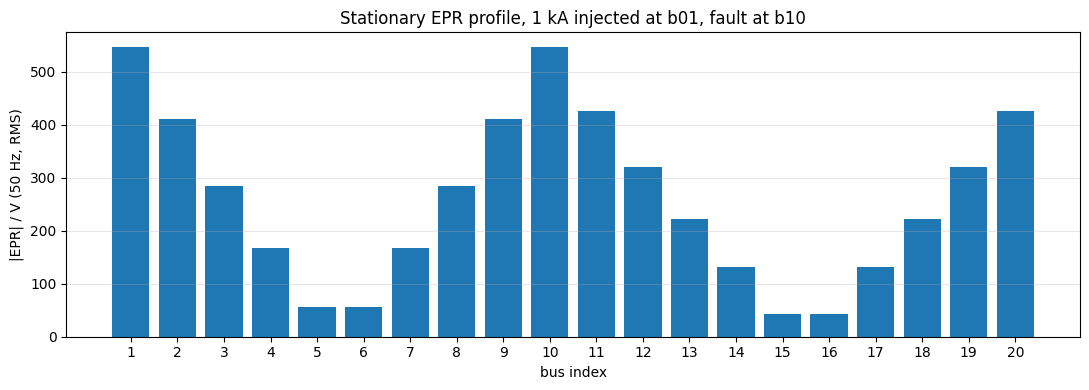

Z_G at fault bus (b10): 0.605 ohm
Reduction factor at 50 Hz: r = 0.904  (1.0 = no shield reduction, 0 = full shield reduction)


In [4]:
gi.create_source(name="src", bus="b01", values={50.0: 1000.0 + 0.0j}, network=net)
gi.create_fault(name="F1", bus="b10", scalings={50.0: 1.0}, network=net)
gi.create_paths(network=net)
gi.run_fault(net, fault_name="F1")

epr_50 = {b.name: b.uepr for b in net.results["F1"].buses}
fig, ax = plt.subplots(figsize=(11, 4))
names = [f"b{k:02d}" for k in range(1, N_BUSES + 1)]
ax.bar(range(1, N_BUSES + 1), [epr_50[n] for n in names], color="tab:blue")
ax.set_xlabel("bus index"); ax.set_ylabel("|EPR| / V (50 Hz, RMS)")
ax.set_title("Stationary EPR profile, 1 kA injected at b01, fault at b10")
ax.set_xticks(range(1, N_BUSES + 1))
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout(); plt.show()

Z_g = net.results["F1"].grounding_impedance.value[50.0]
rf = net.results["F1"].reduction_factor.value[50.0]
print(f"Z_G at fault bus (b10): {abs(complex(Z_g.real, Z_g.imag)):.3f} ohm")
print(f"Reduction factor at 50 Hz: r = {rf:.3f}  (1.0 = no shield reduction, 0 = full shield reduction)")
